In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import sklearn as sk
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [70]:
df = pd.read_csv('crx.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [71]:
df.columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
              'A11', 'A12', 'A13', 'A14', 'A15', 'A16']

print(df.columns)

num_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
str_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16'],
      dtype='str')


In [72]:
df.info()

print('Number of nulls -', df.isnull().sum())
print('Stats -', df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    str    
 1   A2      690 non-null    str    
 2   A3      690 non-null    float64
 3   A4      690 non-null    str    
 4   A5      690 non-null    str    
 5   A6      690 non-null    str    
 6   A7      690 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     690 non-null    str    
 14  A15     690 non-null    int64  
 15  A16     690 non-null    str    
dtypes: float64(2), int64(2), str(12)
memory usage: 100.0 KB
Number of nulls - A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64
Stat

In [73]:
df = df.replace('?', np.nan)

for col in num_cols:
    df[col] = pd.to_numeric(df[col])

df['A16'] = df['A16'].map({'+': 1, '-': 0})

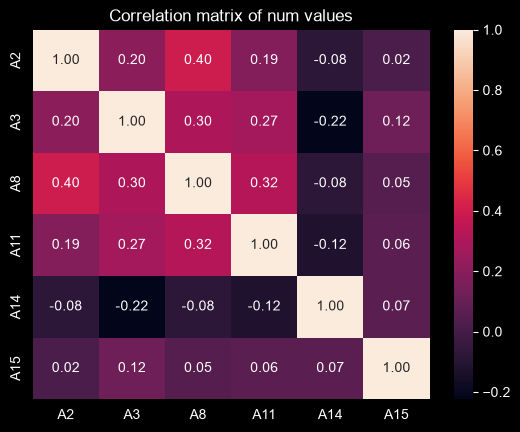

In [74]:
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f')
plt.title('Correlation matrix of num values')
plt.show()

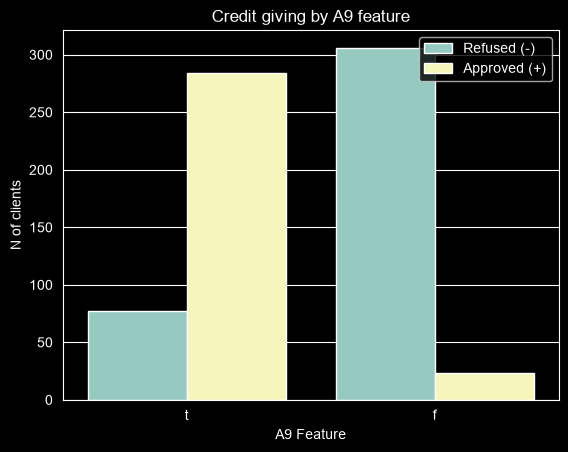

In [75]:
sns.countplot(data=df, x='A9', hue='A16')
plt.title('Credit giving by A9 feature')
plt.xlabel('A9 Feature')
plt.ylabel('N of clients')
plt.legend(['Refused (-)', 'Approved (+)'])
plt.show()

In [76]:
df['A9_and_A10_is_t'] = ((df['A9'] == 't') & (df['A10'] == 't')).astype(int)
df['A9_and_A10_is_f'] = ((df['A9'] == 'f') & (df['A10'] == 'f')).astype(int)

In [77]:
x = df.drop(columns=['A16'])
y = df['A16']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [78]:
num_inputer = SimpleImputer(strategy='median')
sc_num = StandardScaler()

x_train_num = num_inputer.fit_transform(x_train[num_cols])
x_test_num = num_inputer.transform(x_test[num_cols])

x_train_num = sc_num.fit_transform(x_train_num)
x_test_num = sc_num.transform(x_test_num)

In [79]:
str_inputer = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_str = str_inputer.fit_transform(x_train[str_cols])
x_test_str = str_inputer.transform(x_test[str_cols])

x_train_str = encoder.fit_transform(x_train_str)
x_test_str = encoder.transform(x_test_str)

In [80]:
x_train_final = np.hstack((x_train_num, x_train_str))
x_test_final = np.hstack((x_test_num, x_test_str))

In [81]:
model_tree = sk.tree.DecisionTreeClassifier(max_depth=5, random_state=42)
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_knn = KNeighborsClassifier(n_neighbors=5)

model_tree.fit(x_train_final, y_train)
model_lr.fit(x_train_final, y_train)
model_knn.fit(x_train_final, y_train)

y_pred_tr = model_tree.predict(x_test_final)
y_pred_lr = model_lr.predict(x_test_final)
y_pred_knn = model_knn.predict(x_test_final)

In [82]:
print('Score DecisionTreeClassifier:', accuracy_score(y_test, y_pred_tr))
print('Score LogisticRegression:', accuracy_score(y_test, y_pred_lr))
print('Score KNeighborsClassifier:', accuracy_score(y_test, y_pred_knn))

Score DecisionTreeClassifier: 0.8188405797101449
Score LogisticRegression: 0.8260869565217391
Score KNeighborsClassifier: 0.8115942028985508
